In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# 日本語のmatplotlib設定
plt.rcParams["font.family"] = "IPAexGothic"  # 日本語フォントを指定
plt.rcParams["axes.unicode_minus"] = False  # マイナス記号を正しく表示
import japanize_matplotlib 

def mc(x0=None, times=100, trans_prob=None, labels=None):
    """
    マルコフ連鎖シミュレーション

    Parameters
    ----------
    x0 : list of float, optional
        初期確率分布（デフォルト: 状態0が確率1）
    times : int
        状態遷移の回数（デフォルト: 100）
    trans_prob : np.ndarray, shape (n, n)
        遷移確率行列（列の和が1）
        trans_prob[i, j] = 状態j → 状態iの遷移確率
    labels : list of str, optional
        各状態のラベル

    Returns
    -------
    state : np.ndarray, shape (times, n)
        各ステップの確率分布の推移
    """
    n = trans_prob.shape[0]
    print(f"状態数: {n}, シミュレーション回数: {times}")

    if x0 is None:
        x0 = [1.0] + [0.0] * (n - 1)

    if labels is None:
        labels = [f"状態{i}" for i in range(n)]

    x = np.array(x0, dtype=float).reshape(-1, 1)
    state = np.zeros((times, n))
    state[0] = x.ravel()

    for i in range(times - 1):
        x = trans_prob @ x
        state[i + 1] = x.ravel()

    return state


def plot_mc(state, labels=None, title="マルコフ連鎖の収束"):
    """
    シミュレーション結果をプロット

    Parameters
    ----------
    state : np.ndarray
        mc() の返り値
    labels : list of str, optional
        各状態のラベル
    title : str
        グラフタイトル
    """
    n = state.shape[1]
    if labels is None:
        labels = [f"状態{i}" for i in range(n)]

    fig, ax = plt.subplots(figsize=(8, 4))
    for i in range(n):
        ax.plot(state[:, i], label=labels[i])

    ax.set_xlabel("ステップ数")
    ax.set_ylabel("確率")
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # 遷移確率行列（列の和が1になるように定義）
    # trans_prob[i, j] = 状態j → 状態i の遷移確率
    trans_prob = np.array([
        [0.8, 0.15, 0.05],   # → 晴れ
        [0.15, 0.6,  0.3 ],  # → くもり
        [0.05, 0.25, 0.65],  # → 雨
    ])

    labels = ["晴れ", "くもり", "雨"]

    # 晴れから始まるケース
    state_sunny = mc(
        x0=[1.0, 0.0, 0.0],
        times=30,
        trans_prob=trans_prob,
        labels=labels,
    )
    plot_mc(state_sunny, labels=labels, title="初期状態: 晴れ")

    # 雨から始まるケース
    state_rainy = mc(
        x0=[0.0, 0.0, 1.0],
        times=30,
        trans_prob=trans_prob,
        labels=labels,
    )
    plot_mc(state_rainy, labels=labels, title="初期状態: 雨")

    # 定常分布の確認（固有値から解析的に求める）
    eigenvalues, eigenvectors = np.linalg.eig(trans_prob)
    idx = np.argmin(np.abs(eigenvalues - 1.0))  # 固有値1に対応するベクトル
    stationary = np.real(eigenvectors[:, idx])
    stationary /= stationary.sum()
    print("定常分布:", dict(zip(labels, stationary.round(4))))

状態数: 3, シミュレーション回数: 30


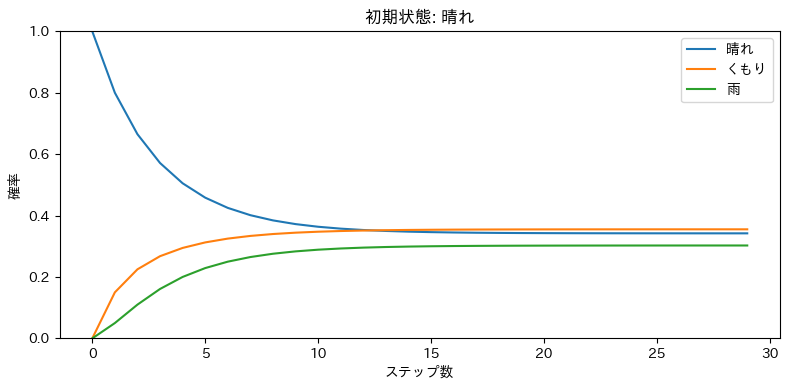

状態数: 3, シミュレーション回数: 30


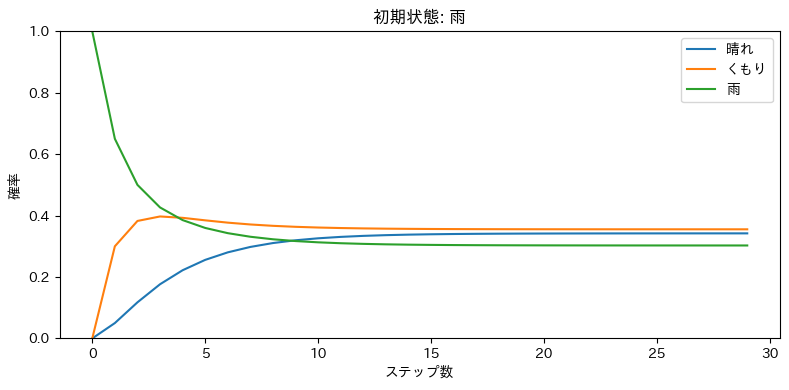

定常分布: {'晴れ': 0.3421, 'くもり': 0.3553, '雨': 0.3026}


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# 日本語のmatplotlib設定
plt.rcParams["font.family"] = "IPAexGothic"  # 日本語フォントを指定
plt.rcParams["axes.unicode_minus"] = False  # マイナス記号を正しく表示
import japanize_matplotlib 

def mc(x0=None, times=100, trans_prob=None, labels=None):
    """
    マルコフ連鎖シミュレーション

    Parameters
    ----------
    x0 : list of float, optional
        初期確率分布（デフォルト: 状態0が確率1）
    times : int
        状態遷移の回数（デフォルト: 100）
    trans_prob : np.ndarray, shape (n, n)
        遷移確率行列（列の和が1）
        trans_prob[i, j] = 状態j → 状態iの遷移確率
    labels : list of str, optional
        各状態のラベル

    Returns
    -------
    state : np.ndarray, shape (times, n)
        各ステップの確率分布の推移
    """
    n = trans_prob.shape[0]
    print(f"状態数: {n}, シミュレーション回数: {times}")

    if x0 is None:
        x0 = [1.0] + [0.0] * (n - 1)

    if labels is None:
        labels = [f"状態{i}" for i in range(n)]

    x = np.array(x0, dtype=float).reshape(-1, 1)
    state = np.zeros((times, n))
    state[0] = x.ravel()

    for i in range(times - 1):
        x = trans_prob @ x
        state[i + 1] = x.ravel()

    return state


def plot_mc(state, labels=None, title="マルコフ連鎖の収束"):
    """
    シミュレーション結果をプロット

    Parameters
    ----------
    state : np.ndarray
        mc() の返り値
    labels : list of str, optional
        各状態のラベル
    title : str
        グラフタイトル
    """
    n = state.shape[1]
    if labels is None:
        labels = [f"状態{i}" for i in range(n)]

    fig, ax = plt.subplots(figsize=(8, 4))
    for i in range(n):
        ax.plot(state[:, i], label=labels[i])

    ax.set_xlabel("ステップ数")
    ax.set_ylabel("確率")
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # 遷移確率行列（列の和が1になるように定義）
    # trans_prob[i, j] = 状態j → 状態i の遷移確率
    trans_prob = np.array([
        [0.8, 0.15, 0.05],   # → 晴れ
        [0.15, 0.6,  0.3 ],  # → くもり
        [0.05, 0.25, 0.65],  # → 雨
    ])

    labels = ["晴れ", "くもり", "雨"]

    # 晴れから始まるケース
    state_sunny = mc(
        x0=[1.0, 0.0, 0.0],
        times=30,
        trans_prob=trans_prob,
        labels=labels,
    )
    plot_mc(state_sunny, labels=labels, title="初期状態: 晴れ")

    # 雨から始まるケース
    state_rainy = mc(
        x0=[0.0, 0.0, 1.0],
        times=30,
        trans_prob=trans_prob,
        labels=labels,
    )
    plot_mc(state_rainy, labels=labels, title="初期状態: 雨")

    # 定常分布の確認（固有値から解析的に求める）
    eigenvalues, eigenvectors = np.linalg.eig(trans_prob)
    idx = np.argmin(np.abs(eigenvalues - 1.0))  # 固有値1に対応するベクトル
    stationary = np.real(eigenvectors[:, idx])
    stationary /= stationary.sum()
    print("定常分布:", dict(zip(labels, stationary.round(4))))
    